# Bayesian Dixon–Coles notebook

This notebook implements a simple Bayesian version of a Dixon–Coles-style goal model. Instead of fitting one global model once, it walks through the matches sequentially and refits the model after each new game so that the posterior from the previous step becomes the starting point for the next one.

The implementation uses weakly informative priors, a draw-adjustment term for 0-0 and 1-1 scorelines, and a small, notebook-friendly setup so it can run without requiring a large amount of compute.


In [1]:
import os
import math
import warnings
import sys
import tqdm
from pathlib import Path


def ensure_project_venv_on_path():
    """Add the repository virtual environment site-packages to sys.path when available."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidates = [
            base / ".venv" / "lib" / f"python{sys.version_info.major}.{sys.version_info.minor}" / "site-packages",
            base / ".venv" / "Lib" / "site-packages",
        ]
        for candidate in candidates:
            if candidate.exists() and str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
                return str(candidate)
    return None


ensure_project_venv_on_path()

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ── Data loading ──────────────────────────────────────────────────────────────
# All CSVs matching the pattern in data/ are loaded and concatenated automatically.
# To add new season data, just drop a new file (e.g. finland_5_6_7_divisions_results_26.csv)
# into the data/ directory and re-run this cell.

def load_matches(data_dir=None):
    """Load and concatenate all finland_5_6_7_divisions_results_*.csv files found in data_dir."""
    if data_dir is None:
        for base in [Path.cwd(), Path.cwd().parent]:
            candidate = base / "data"
            if candidate.exists():
                data_dir = candidate
                break
    if data_dir is None:
        raise FileNotFoundError("Could not locate the data/ directory.")

    csv_files = sorted(Path(data_dir).glob("finland_5_6_7_divisions_results_*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No matching CSV files found in {data_dir}")

    frames = [pd.read_csv(p) for p in csv_files]
    df = pd.concat(frames, ignore_index=True)
    df = df.drop_duplicates(subset=["team_home", "team_away", "goals_home", "goals_away", "season", "group"])
    df = df.loc[df["league_division"].isin([5, 6, 7])].copy()
    df = df.rename(columns={"team_home": "home_team", "team_away": "away_team",
                             "goals_home": "home_goals", "goals_away": "away_goals"})
    df = df.sort_values(["season", "group", "league_division"]).reset_index(drop=True)
    print(f"Loaded {len(df):,} matches (seasons {sorted(df['season'].unique())}) "
          f"from {len(csv_files)} file(s): {[p.name for p in csv_files]}")
    return df


display = lambda value: print(value)
matches = load_matches()
matches.head()


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Loaded 8,862 matches (seasons [20, 21, 22, 23, 24, 25]) from 1 file(s): ['finland_5_6_7_divisions_results_20-25.csv']


,home_team,away_team,home_goals,away_goals,league_division,season,group
0,Tikka/2,LoPa/2,5,0,6,20,1
1,LJS/Reservi,ViTa,1,2,6,20,1
2,FC Slimmit,BK-46/Hobby,0,5,6,20,1
3,RPS 32,FC Kirkkonummi/3,0,6,6,20,1
4,HooGee/Hodari,KJS,3,5,6,20,1


In [2]:
# Filter to the seasons you want to include in the model.
# Add 26 here once its data lands in the CSV; it will be picked up automatically.
seasons_to_use = [20, 21, 22, 23, 24, 25, 26]

matches = matches[(matches["season"].isin(seasons_to_use))].copy().reset_index(drop=True)

all_teams = sorted(set(matches["home_team"]).union(matches["away_team"]))
team_to_idx = {team: i for i, team in enumerate(all_teams)}

matches["home_idx"] = matches["home_team"].map(team_to_idx)
matches["away_idx"] = matches["away_team"].map(team_to_idx)

display(matches[["home_team", "away_team", "home_goals", "away_goals", "season"]].head())
display(matches.shape)


       home_team         away_team  home_goals  away_goals  season
0        Tikka/2            LoPa/2           5           0      20
1    LJS/Reservi              ViTa           1           2      20
2     FC Slimmit       BK-46/Hobby           0           5      20
3         RPS 32  FC Kirkkonummi/3           0           6      20
4  HooGee/Hodari               KJS           3           5      20
(8862, 9)


## Model specification

The model uses a Poisson likelihood for home and away goals, with a Dixon–Coles adjustment that slightly increases the probability of draws when both teams score a low number of goals. Team strength is represented by team-specific attack and defense effects, together with a shared home advantage parameter.

To keep the coefficients identifiable, the attack and defense effects are centered so that they sum to zero across teams.

In [3]:
import pytensor.tensor as pt


def dixon_coles_logp(home_goals, away_goals, home_attack, away_attack, home_defense, away_defense, home_adv, rho):
    """Vectorized log-likelihood for a simple Bayesian Dixon–Coles model."""
    home_goals = pt.flatten(home_goals)
    away_goals = pt.flatten(away_goals)

    home_rate = pt.exp(home_adv + home_attack - away_defense)
    away_rate = pt.exp(away_attack - home_defense)

    logp_home = home_goals * pt.log(home_rate) - home_rate - pt.gammaln(home_goals + 1.0)
    logp_away = away_goals * pt.log(away_rate) - away_rate - pt.gammaln(away_goals + 1.0)

    draw_mask_home = pt.eq(home_goals, 0) & pt.eq(away_goals, 0)
    draw_mask_draw = pt.eq(home_goals, 1) & pt.eq(away_goals, 1)
    draw_correction = pt.where(draw_mask_home, 1.0 - rho, pt.where(draw_mask_draw, 1.0 + rho, 1.0))

    return pt.sum(logp_home + logp_away + pt.log(draw_correction))


def fit_full_model(matches, draws=80, tune=80):
    """Fit the Bayesian Dixon–Coles model once to all selected matches."""
    home_goals = matches["home_goals"].to_numpy(dtype="float64")
    away_goals = matches["away_goals"].to_numpy(dtype="float64")
    home_idx = matches["home_idx"].to_numpy(dtype="int64")
    away_idx = matches["away_idx"].to_numpy(dtype="int64")

    with pm.Model() as model:
        attack_raw = pm.Normal("attack_raw", mu=0.0, sigma=1.0, shape=len(all_teams))
        defense_raw = pm.Normal("defense_raw", mu=0.0, sigma=1.0, shape=len(all_teams))
        attack = pm.Deterministic("attack", attack_raw - pm.math.mean(attack_raw))
        defense = pm.Deterministic("defense", defense_raw - pm.math.mean(defense_raw))
        home_adv = pm.Normal("home_adv", mu=0.0, sigma=1.0)
        rho = pm.TruncatedNormal("rho", mu=0.05, sigma=0.05, lower=0.0, upper=0.2)

        home_attack = attack[home_idx]
        away_attack = attack[away_idx]
        home_defense = defense[home_idx]
        away_defense = defense[away_idx]

        log_likelihood = dixon_coles_logp(
            home_goals, away_goals,
            home_attack, away_attack,
            home_defense, away_defense,
            home_adv, rho,
        )
        pm.Potential("match_likelihood", log_likelihood)

        trace = pm.sample(
            draws=draws, tune=tune, chains=1, cores=1,
            progressbar=True, target_accept=0.9, random_seed=42, init="auto",
        )

    summary = az.summary(trace.posterior, var_names=["home_adv", "rho", "attack", "defense"], hdi_prob=0.95)
    summary = summary.reset_index().rename(columns={"index": "parameter_name"})

    if "hdi_3%" in summary.columns:
        lower_col, upper_col = "hdi_3%", "hdi_97%"
    elif "hdi_2.5%" in summary.columns:
        lower_col, upper_col = "hdi_2.5%", "hdi_97.5%"
    else:
        lower_col, upper_col = None, None

    summary["parameter"] = summary["parameter_name"].str.extract(r"^(attack|defense|home_adv|rho)")
    summary["team_idx"] = summary["parameter_name"].str.extract(r"\[(\d+)\]")
    summary["team_idx"] = pd.to_numeric(summary["team_idx"], errors="coerce")
    summary["team_name"] = summary["team_idx"].map(lambda i: all_teams[int(i)] if pd.notna(i) else np.nan)

    if lower_col is not None and upper_col is not None:
        summary = summary[
            ["parameter", "parameter_name", "team_name", "team_idx", "mean", "sd", lower_col, upper_col]
        ].rename(columns={lower_col: "hdi_lower", upper_col: "hdi_upper"})
    else:
        summary = summary[["parameter", "parameter_name", "team_name", "team_idx", "mean", "sd"]]
        summary["hdi_lower"] = np.nan
        summary["hdi_upper"] = np.nan

    return trace, summary


def fit_temporal_model(matches, draws=60, tune=60, prior_sigma=0.4, min_matches=5):
    """Fit a joint temporal model with a random-walk prior across seasons."""
    season_ids = matches["season"].astype(int).to_numpy(dtype="int64")
    seasons = np.sort(np.unique(season_ids))
    season_to_idx = {season: i for i, season in enumerate(seasons)}
    season_idx = np.array([season_to_idx[s] for s in season_ids], dtype="int64")

    home_goals = matches["home_goals"].to_numpy(dtype="float64")
    away_goals = matches["away_goals"].to_numpy(dtype="float64")
    home_idx = matches["home_idx"].to_numpy(dtype="int64")
    away_idx = matches["away_idx"].to_numpy(dtype="int64")

    n_seasons = len(seasons)
    n_teams = len(all_teams)

    with pm.Model() as model:
        attack_list = []
        defense_list = []

        for season in range(n_seasons):
            if season == 0:
                attack_prev = 0.0
                defense_prev = 0.0
            else:
                attack_prev = attack_list[-1]
                defense_prev = defense_list[-1]

            attack_s = pm.Normal(f"attack_{season}", mu=attack_prev, sigma=prior_sigma, shape=n_teams)
            defense_s = pm.Normal(f"defense_{season}", mu=defense_prev, sigma=prior_sigma, shape=n_teams)

            attack_list.append(pm.Deterministic(f"attack_centered_{season}", attack_s - pm.math.mean(attack_s)))
            defense_list.append(pm.Deterministic(f"defense_centered_{season}", defense_s - pm.math.mean(defense_s)))

        attack = pt.stack(attack_list)
        defense = pt.stack(defense_list)
        home_adv = pm.Normal("home_adv", mu=0.0, sigma=1.0)
        rho = pm.TruncatedNormal("rho", mu=0.05, sigma=0.05, lower=0.0, upper=0.2)

        home_attack = attack[season_idx, home_idx]
        away_attack = attack[season_idx, away_idx]
        home_defense = defense[season_idx, home_idx]
        away_defense = defense[season_idx, away_idx]

        log_likelihood = dixon_coles_logp(
            home_goals, away_goals,
            home_attack, away_attack,
            home_defense, away_defense,
            home_adv, rho,
        )
        pm.Potential("match_likelihood", log_likelihood)

        trace = pm.sample(
            draws=draws, tune=tune, chains=1, cores=1,
            progressbar=False, target_accept=0.9, random_seed=42, init="auto",
        )

    attack_means = []
    defense_means = []
    for season in range(n_seasons):
        attack_means.append(np.asarray(trace.posterior[f"attack_centered_{season}"].values).mean(axis=(0, 1)))
        defense_means.append(np.asarray(trace.posterior[f"defense_centered_{season}"].values).mean(axis=(0, 1)))

    evolution_rows = []
    for season_idx_value, season in enumerate(seasons):
        for team_idx, team_name in enumerate(all_teams):
            evolution_rows.append({"season": int(season), "team": team_name, "parameter": "attack",  "mean": attack_means[season_idx_value][team_idx]})
            evolution_rows.append({"season": int(season), "team": team_name, "parameter": "defense", "mean": defense_means[season_idx_value][team_idx]})

    evolution_df = pd.DataFrame(evolution_rows)
    return {"trace": trace, "evolution": evolution_df,
            "attack": np.vstack(attack_means), "defense": np.vstack(defense_means), "seasons": seasons}


def plot_temporal_strength_evolution(evolution_df, team_name):
    """Plot how attack and defense estimates change across seasons for a selected team."""
    subset = evolution_df[evolution_df["team"] == team_name].copy()
    plt.figure(figsize=(10, 4))
    for parameter in ["attack", "defense"]:
        parameter_subset = subset[subset["parameter"] == parameter]
        plt.plot(parameter_subset["season"], parameter_subset["mean"], marker="o", label=parameter)

    plt.xticks(sorted(subset["season"].unique()))
    plt.title(f"Temporal strength evolution for {team_name}")
    plt.xlabel("Season")
    plt.ylabel("Posterior mean effect")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ── Within-season evolution ───────────────────────────────────────────────────

def fit_within_season_model(matches, season, n_windows=10, draws=60, tune=60, prior_sigma=0.3, ci=0.68,
                             prior_attack_means=None, prior_defense_means=None, sigma_first_window=None):
    """
    Track how team strengths evolve within a single season.

    Each row in the dataset is treated as one time point. The season's matches
    are split in their existing order into `n_windows` equal-sized windows.
    A temporal random-walk prior connects adjacent windows.

    Parameters
    ----------
    matches              : DataFrame with 'season', 'home_team', 'away_team',
                           'home_goals', 'away_goals' columns.
    season               : int   – which season to analyse (e.g. 26).
    n_windows            : int   – number of time windows (default 10).
    prior_sigma          : float – within-season window-to-window drift.
    ci                   : float – credible interval width (default 0.68).
    prior_attack_means   : dict  – {team_name: mean} from previous season's last window.
    prior_defense_means  : dict  – same for defense.
    sigma_first_window   : float – uncertainty on the first window; defaults to prior_sigma.
                           Set larger than prior_sigma to allow more inter-season change.

    Returns
    -------
    dict with keys: trace, evolution (DataFrame with mean/lower/upper),
                    season_teams, window_labels, team_active_windows, ci.
    """
    season_matches = matches[matches["season"] == season].copy().reset_index(drop=True)
    if len(season_matches) == 0:
        raise ValueError(f"No matches found for season {season}. "
                         "Add the CSV file and re-run the data loading cell.")

    n_matches = len(season_matches)
    matches_per_window = max(1, n_matches // n_windows)
    season_matches["window"] = np.minimum(season_matches.index // matches_per_window, n_windows - 1)

    actual_windows = sorted(season_matches["window"].unique())
    n_windows_actual = len(actual_windows)
    window_to_idx = {w: i for i, w in enumerate(actual_windows)}
    window_idx = season_matches["window"].map(window_to_idx).to_numpy(dtype="int64")

    window_match_bounds: dict = {}
    for row_i, w in enumerate(season_matches["window"]):
        w_idx = window_to_idx[w]
        window_match_bounds.setdefault(w_idx, []).append(row_i + 1)
    window_labels = {w_idx: f"match {min(ms)}–{max(ms)}"
                     for w_idx, ms in window_match_bounds.items()}

    season_teams = sorted(set(season_matches["home_team"]).union(season_matches["away_team"]))
    s_team_to_idx = {t: i for i, t in enumerate(season_teams)}
    home_idx = season_matches["home_team"].map(s_team_to_idx).to_numpy(dtype="int64")
    away_idx = season_matches["away_team"].map(s_team_to_idx).to_numpy(dtype="int64")
    home_goals = season_matches["home_goals"].to_numpy(dtype="float64")
    away_goals = season_matches["away_goals"].to_numpy(dtype="float64")
    n_teams = len(season_teams)

    # First-window prior: use previous season's posterior if provided, else zero
    if sigma_first_window is None:
        sigma_first_window = prior_sigma
    if prior_attack_means is not None:
        first_attack_mu  = np.array([prior_attack_means.get(t, 0.0)  for t in season_teams])
        first_defense_mu = np.array([prior_defense_means.get(t, 0.0) for t in season_teams])
    else:
        first_attack_mu  = np.zeros(n_teams)
        first_defense_mu = np.zeros(n_teams)

    with pm.Model() as model:
        attack_list = []
        defense_list = []

        for w in range(n_windows_actual):
            if w == 0:
                attack_w  = pm.Normal(f"attack_{w}",  mu=first_attack_mu,  sigma=sigma_first_window, shape=n_teams)
                defense_w = pm.Normal(f"defense_{w}", mu=first_defense_mu, sigma=sigma_first_window, shape=n_teams)
            else:
                attack_w  = pm.Normal(f"attack_{w}",  mu=attack_list[-1],  sigma=prior_sigma, shape=n_teams)
                defense_w = pm.Normal(f"defense_{w}", mu=defense_list[-1], sigma=prior_sigma, shape=n_teams)

            attack_list.append(pm.Deterministic(f"attack_centered_{w}",  attack_w  - pm.math.mean(attack_w)))
            defense_list.append(pm.Deterministic(f"defense_centered_{w}", defense_w - pm.math.mean(defense_w)))

        attack  = pt.stack(attack_list)
        defense = pt.stack(defense_list)
        home_adv = pm.Normal("home_adv", mu=0.0, sigma=1.0)
        rho = pm.TruncatedNormal("rho", mu=0.05, sigma=0.05, lower=0.0, upper=0.2)

        home_attack  = attack[window_idx,  home_idx]
        away_attack  = attack[window_idx,  away_idx]
        home_defense = defense[window_idx, home_idx]
        away_defense = defense[window_idx, away_idx]

        pm.Potential("match_likelihood", dixon_coles_logp(
            home_goals, away_goals,
            home_attack, away_attack,
            home_defense, away_defense,
            home_adv, rho,
        ))

        trace = pm.sample(
            draws=draws, tune=tune, chains=1, cores=1,
            progressbar=True, target_accept=0.9, random_seed=42, init="auto",
        )

    lo_p = (1.0 - ci) / 2.0 * 100
    hi_p = (1.0 - (1.0 - ci) / 2.0) * 100

    rows = []
    for w in range(n_windows_actual):
        att_samples = np.asarray(trace.posterior[f"attack_centered_{w}"].values).reshape(-1, n_teams)
        def_samples = np.asarray(trace.posterior[f"defense_centered_{w}"].values).reshape(-1, n_teams)
        for t_idx, team_name in enumerate(season_teams):
            rows.append({
                "window": w, "label": window_labels[w], "team": team_name,
                "parameter": "attack",
                "mean":  att_samples[:, t_idx].mean(),
                "lower": np.percentile(att_samples[:, t_idx], lo_p),
                "upper": np.percentile(att_samples[:, t_idx], hi_p),
            })
            rows.append({
                "window": w, "label": window_labels[w], "team": team_name,
                "parameter": "defense",
                "mean":  def_samples[:, t_idx].mean(),
                "lower": np.percentile(def_samples[:, t_idx], lo_p),
                "upper": np.percentile(def_samples[:, t_idx], hi_p),
            })

    team_active_windows: dict = {}
    for _, row in season_matches.iterrows():
        w_idx = window_to_idx[row["window"]]
        for team in [row["home_team"], row["away_team"]]:
            team_active_windows.setdefault(team, set()).add(w_idx)

    return {
        "trace": trace,
        "evolution": pd.DataFrame(rows),
        "season_teams": season_teams,
        "window_labels": window_labels,
        "team_active_windows": team_active_windows,
        "ci": ci,
    }


def plot_within_season_evolution(result, team_name, season=None):
    """Plot attack and defense estimates with credible intervals for one team.

    Only windows in which the team actually played a match are shown.
    """
    evo = result["evolution"]
    ci  = result.get("ci", 0.68)
    subset = evo[evo["team"] == team_name].copy()
    if subset.empty:
        raise ValueError(f"'{team_name}' not found. Available: {sorted(evo['team'].unique())[:10]}")

    active = result.get("team_active_windows", {}).get(team_name)
    if active is not None:
        subset = subset[subset["window"].isin(active)]

    windows = sorted(subset["window"].unique())
    labels  = [result["window_labels"][w] for w in windows]
    colors  = {"attack": "C0", "defense": "C1"}

    fig, ax = plt.subplots(figsize=(max(8, len(windows) * 1.4), 4))
    for parameter in ["attack", "defense"]:
        p = subset[subset["parameter"] == parameter].sort_values("window")
        c = colors[parameter]
        ax.plot(p["window"], p["mean"], marker="o", color=c, label=parameter)
        ax.fill_between(p["window"], p["lower"], p["upper"],
                        alpha=0.20, color=c, label=f"{int(ci*100)}% CI ({parameter})")

    ax.set_xticks(windows)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    title = f"Within-season strength evolution — {team_name}"
    if season is not None:
        title += f" (season {season})"
    ax.set_title(title)
    ax.set_xlabel("Match window (season order)")
    ax.set_ylabel("Posterior mean effect")
    ax.legend()
    plt.tight_layout()
    plt.show()


# ── Multi-season evolution ────────────────────────────────────────────────────

def fit_all_seasons_model(matches, seasons=None, n_windows=10, draws=60, tune=60, prior_sigma=0.3, ci=0.68):
    """Fit within-season models independently for every season and combine."""
    if seasons is None:
        seasons = sorted(matches["season"].unique())

    all_evolution            = []
    all_window_labels: dict  = {}
    all_team_active_windows: dict = {}
    season_boundaries: dict  = {}
    global_offset            = 0

    for season in seasons:
        if len(matches[matches["season"] == season]) == 0:
            print(f"Season {season}: no data, skipping.")
            continue

        print(f"\n── Season {season} ──")
        result = fit_within_season_model(
            matches, season=season, n_windows=n_windows,
            draws=draws, tune=tune, prior_sigma=prior_sigma, ci=ci,
        )

        n_w = len(result["window_labels"])
        season_boundaries[season] = (global_offset, global_offset + n_w - 1)

        evo = result["evolution"].copy()
        evo["window"] = evo["window"] + global_offset
        evo["season"] = season
        all_evolution.append(evo)

        for w_local, label in result["window_labels"].items():
            all_window_labels[w_local + global_offset] = label

        for team, active_set in result["team_active_windows"].items():
            shifted = {w + global_offset for w in active_set}
            all_team_active_windows.setdefault(team, set()).update(shifted)

        global_offset += n_w

    return {
        "evolution":           pd.concat(all_evolution, ignore_index=True),
        "window_labels":       all_window_labels,
        "team_active_windows": all_team_active_windows,
        "season_boundaries":   season_boundaries,
        "ci":                  ci,
    }


def fit_joint_seasonal_model(matches, seasons=None, n_windows=10, draws=60, tune=60,
                              sigma_within=0.3, sigma_between=0.8, ci=0.68):
    """
    Fit within-season models sequentially, carrying information across seasons.

    Each season's first window is warm-started from the previous season's
    final-window posterior means. `sigma_between` controls how much drift is
    allowed at each season transition: larger values let the model respond
    more freely to inter-season strength changes.

    Parameters
    ----------
    sigma_within  : within-season window-to-window drift.
    sigma_between : uncertainty injected at each season boundary (should be
                    larger than sigma_within to allow inter-season change).
    """
    if seasons is None:
        seasons = sorted(matches["season"].unique())

    all_evolution            = []
    all_window_labels: dict  = {}
    all_team_active_windows: dict = {}
    season_boundaries: dict  = {}
    global_offset            = 0
    prior_attack_means       = None
    prior_defense_means      = None

    for season in seasons:
        if len(matches[matches["season"] == season]) == 0:
            print(f"Season {season}: no data, skipping.")
            continue

        is_first = prior_attack_means is None
        label = "cold start" if is_first else f"warm start (sigma_between={sigma_between})"
        print(f"\n── Season {season} ({label}) ──")

        result = fit_within_season_model(
            matches, season=season, n_windows=n_windows,
            draws=draws, tune=tune,
            prior_sigma=sigma_within, ci=ci,
            prior_attack_means=prior_attack_means,
            prior_defense_means=prior_defense_means,
            sigma_first_window=1.0 if is_first else sigma_between,
        )

        # Extract last-window posterior means to seed the next season
        season_teams = result["season_teams"]
        last_w = len(result["window_labels"]) - 1
        att_s = np.asarray(result["trace"].posterior[f"attack_centered_{last_w}"].values).reshape(-1, len(season_teams))
        def_s = np.asarray(result["trace"].posterior[f"defense_centered_{last_w}"].values).reshape(-1, len(season_teams))
        prior_attack_means  = {t: att_s[:, i].mean() for i, t in enumerate(season_teams)}
        prior_defense_means = {t: def_s[:, i].mean() for i, t in enumerate(season_teams)}

        n_w = len(result["window_labels"])
        season_boundaries[season] = (global_offset, global_offset + n_w - 1)

        evo = result["evolution"].copy()
        evo["window"] = evo["window"] + global_offset
        evo["season"] = season
        all_evolution.append(evo)

        for w_local, lbl in result["window_labels"].items():
            all_window_labels[w_local + global_offset] = lbl

        for team, active_set in result["team_active_windows"].items():
            shifted = {w + global_offset for w in active_set}
            all_team_active_windows.setdefault(team, set()).update(shifted)

        global_offset += n_w

    return {
        "evolution":            pd.concat(all_evolution, ignore_index=True),
        "window_labels":        all_window_labels,
        "team_active_windows":  all_team_active_windows,
        "season_boundaries":    season_boundaries,
        "ci":                   ci,
    }


def plot_all_seasons_evolution(result, team_name):
    """
    Plot within- and between-season strength evolution for one team.

    Season boundaries are marked with dashed vertical lines.
    Only match windows where the team played are shown.
    """
    evo = result["evolution"]
    ci  = result.get("ci", 0.68)
    subset = evo[evo["team"] == team_name].copy()
    if subset.empty:
        raise ValueError(f"'{team_name}' not found. Available: {sorted(evo['team'].unique())[:10]}")

    active = result.get("team_active_windows", {}).get(team_name)
    if active is not None:
        subset = subset[subset["window"].isin(active)]

    if subset.empty:
        print(f"'{team_name}' had no active windows in any season.")
        return

    windows = sorted(subset["window"].unique())
    colors  = {"attack": "C0", "defense": "C1"}

    fig, ax = plt.subplots(figsize=(max(12, len(windows) * 0.9), 4))

    for parameter in ["attack", "defense"]:
        p = subset[subset["parameter"] == parameter].sort_values("window")
        c = colors[parameter]
        ax.plot(p["window"], p["mean"], marker="o", markersize=4, color=c, label=parameter)
        ax.fill_between(p["window"], p["lower"], p["upper"],
                        alpha=0.20, color=c, label=f"{int(ci*100)}% CI ({parameter})")

    for i, (season, (start, end)) in enumerate(sorted(result["season_boundaries"].items())):
        mid = (start + end) / 2.0
        if i > 0:
            ax.axvline(x=start - 0.5, color="gray", linestyle="--", alpha=0.5, linewidth=1.0)
        ax.text(mid, 1.02, f"Season {season}",
                ha="center", va="bottom", fontsize=8, color="gray",
                transform=ax.get_xaxis_transform())

    step = max(1, len(windows) // 14)
    tick_wins = windows[::step]
    ax.set_xticks(tick_wins)
    ax.set_xticklabels([result["window_labels"][w] for w in tick_wins], rotation=40, ha="right", fontsize=7)

    ax.set_title(f"Strength evolution across all seasons — {team_name}")
    ax.set_xlabel("Match window within season")
    ax.set_ylabel("Posterior mean effect")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


## Other functions

In [4]:
def predict_match_outcomes(home_team, away_team, trace, team_to_idx, all_teams, max_goals=10):
    """Estimate home-win, draw, and away-win probabilities for a matchup from the posterior samples."""
    if home_team not in team_to_idx or away_team not in team_to_idx:
        raise ValueError(f"Unknown team name. Available teams include: {', '.join(all_teams[:10])} ...")

    home_idx = team_to_idx[home_team]
    away_idx = team_to_idx[away_team]

    attack = np.asarray(trace.posterior["attack"].values).reshape(-1, len(all_teams))
    defense = np.asarray(trace.posterior["defense"].values).reshape(-1, len(all_teams))
    home_adv = np.asarray(trace.posterior["home_adv"].values).reshape(-1)
    rho = np.asarray(trace.posterior["rho"].values).reshape(-1)

    goals = np.arange(max_goals + 1)
    home_win_prob = np.zeros(len(home_adv))
    draw_prob = np.zeros(len(home_adv))
    away_win_prob = np.zeros(len(home_adv))

    for sample_idx in range(len(home_adv)):
        lambda_home = np.exp(home_adv[sample_idx] + attack[sample_idx, home_idx] - defense[sample_idx, away_idx])
        lambda_away = np.exp(attack[sample_idx, away_idx] - defense[sample_idx, home_idx])

        home_goal_probs = np.array([
            np.exp(g * np.log(lambda_home) - lambda_home - math.lgamma(g + 1.0)) for g in goals
        ], dtype=float)
        away_goal_probs = np.array([
            np.exp(g * np.log(lambda_away) - lambda_away - math.lgamma(g + 1.0)) for g in goals
        ], dtype=float)

        for home_goals_i, p_home in enumerate(home_goal_probs):
            for away_goals_i, p_away in enumerate(away_goal_probs):
                if home_goals_i == 0 and away_goals_i == 0:
                    correction = 1.0 - rho[sample_idx]
                elif home_goals_i == 1 and away_goals_i == 1:
                    correction = 1.0 + rho[sample_idx]
                else:
                    correction = 1.0

                prob = p_home * p_away * correction
                if home_goals_i > away_goals_i:
                    home_win_prob[sample_idx] += prob
                elif home_goals_i == away_goals_i:
                    draw_prob[sample_idx] += prob
                else:
                    away_win_prob[sample_idx] += prob

    return pd.DataFrame(
        {
            "outcome": ["home_win", "draw", "away_win"],
            "probability": [home_win_prob.mean(), draw_prob.mean(), away_win_prob.mean()],
        }
    ).round(4)

In [5]:
def plot_match_probability_matrix(home_team, away_team, trace, team_to_idx, all_teams, max_goals=4):
    """Plot a heatmap of posterior probabilities for each possible scoreline outcome."""
    if home_team not in team_to_idx or away_team not in team_to_idx:
        raise ValueError(f"Unknown team name. Available teams include: {', '.join(all_teams[:10])} ...")

    home_idx = team_to_idx[home_team]
    away_idx = team_to_idx[away_team]

    attack = np.asarray(trace.posterior["attack"].values).reshape(-1, len(all_teams))
    defense = np.asarray(trace.posterior["defense"].values).reshape(-1, len(all_teams))
    home_adv = np.asarray(trace.posterior["home_adv"].values).reshape(-1)
    rho = np.asarray(trace.posterior["rho"].values).reshape(-1)

    goals = np.arange(max_goals + 1)
    score_matrix = np.zeros((len(goals), len(goals)))

    for sample_idx in range(len(home_adv)):
        lambda_home = np.exp(home_adv[sample_idx] + attack[sample_idx, home_idx] - defense[sample_idx, away_idx])
        lambda_away = np.exp(attack[sample_idx, away_idx] - defense[sample_idx, home_idx])

        home_goal_probs = np.array([
            np.exp(g * np.log(lambda_home) - lambda_home - math.lgamma(g + 1.0)) for g in goals
        ], dtype=float)
        away_goal_probs = np.array([
            np.exp(g * np.log(lambda_away) - lambda_away - math.lgamma(g + 1.0)) for g in goals
        ], dtype=float)

        for i, p_home in enumerate(home_goal_probs):
            for j, p_away in enumerate(away_goal_probs):
                if i == 0 and j == 0:
                    correction = 1.0 - rho[sample_idx]
                elif i == 1 and j == 1:
                    correction = 1.0 + rho[sample_idx]
                else:
                    correction = 1.0
                score_matrix[i, j] += p_home * p_away * correction

    score_matrix /= len(home_adv)
    score_df = pd.DataFrame(score_matrix, index=[f"{g}" for g in goals], columns=[f"{g}" for g in goals])
    score_df.index.name = "home_goals"
    score_df.columns.name = "away_goals"

    plt.figure(figsize=(7, 6))
    sns.heatmap(score_df, annot=True, fmt=".3f", cmap="Blues", cbar=True)
    plt.title(f"Posterior scoreline probabilities: {home_team} vs {away_team}")
    plt.xlabel("Away goals")
    plt.ylabel("Home goals")
    plt.tight_layout()
    plt.show()

    return score_df

## Full-data fitting

The sequential approach is useful when you want to mimic learning over time, but for estimating the model from the full historical dataset it is usually simpler and more stable to fit once to all matches at once.


In [ ]:
trace, posterior_summary = fit_full_model(matches, draws=80, tune=80)
posterior_summary.head()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
for parameter in ["home_adv", "rho"]:
    subset = posterior_summary[posterior_summary["parameter"] == parameter]
    ax.bar(parameter, subset.iloc[0]["mean"], yerr=0.0, label=parameter)

ax.set_title("Posterior means for global parameters")
ax.set_xlabel("Parameter")
ax.set_ylabel("Posterior mean")
ax.legend()
plt.tight_layout()
plt.show()

team_posteriors = posterior_summary[posterior_summary["parameter"].isin(["attack", "defense"])]
team_posteriors = team_posteriors[["parameter", "team_name", "mean", "hdi_lower", "hdi_upper"]].copy()
team_posteriors = team_posteriors.sort_values(["parameter", "team_name"])
team_posteriors.head(20)


In [ ]:
team_posteriors[team_posteriors['team_name']=='Trikiinit']

In [ ]:
team_posteriors[team_posteriors["parameter"] == "attack"].sort_values("mean", ascending=False).head(10)

In [ ]:
team_posteriors[team_posteriors["parameter"] == "defense"].sort_values("mean", ascending=False).head(10)

In [ ]:
predict_match_outcomes("Trikiinit", "Valtti/TDJ", trace, team_to_idx, all_teams)

In [ ]:
score_df = plot_match_probability_matrix("Trikiinit", "Valtti/TDJ", trace, team_to_idx, all_teams)

## Time-evolution

In [ ]:
temporal_fit = fit_temporal_model(matches, draws=50, tune=50, prior_sigma=0.4)
temporal_fit["evolution"].head()

In [ ]:
plot_temporal_strength_evolution(temporal_fit["evolution"], 'Trikiinit')

## Updating the model with new data

**Adding new season data (e.g. season 26)**

1. Save results to `data/finland_5_6_7_divisions_results_26.csv` with the same columns as the existing file (`team_home`, `team_away`, `goals_home`, `goals_away`, `league_division`, `season`, `group`).
2. Re-run the **data loading cell** — `load_matches()` scans the `data/` folder automatically.
3. Re-run any model cells you want refreshed.

**Updating mid-season as new results come in**

Just append the new rows to your CSV and repeat steps 2–3. The model re-fits from scratch each time using all available data, so posteriors automatically reflect the latest results.

---

## Within-season evolution

`fit_within_season_model` groups a season's rounds into windows (default: 4 rounds each) and fits the same temporal random-walk model within the season. This lets you see whether a team is improving or declining as the season progresses.


In [ ]:
# Within-season evolution example.
# Once season 26 data is loaded, set SEASON = 26 and re-run.
# n_windows controls how many time slices the season is split into.
# Each slice contains roughly len(season_matches) // n_windows consecutive matches.

SEASON = 25        # ← change to 26 when data is available
N_WINDOWS = 10     # ← adjust for coarser/finer resolution

within_season_result = fit_within_season_model(
    matches,
    season=SEASON,
    n_windows=N_WINDOWS,
    draws=60,
    tune=60,
)
within_season_result["evolution"].head(16)


In [ ]:
# Plot within-season evolution for a specific team.
# Replace 'Trikiinit' with any team that plays in the chosen season.
plot_within_season_evolution(within_season_result, "Trikiinit", season=SEASON)


## All-seasons evolution

`fit_joint_seasonal_model` fits within-season models sequentially, carrying the previous season's final-window posterior forward as the prior for the next season's first window. `sigma_between` controls how much drift is allowed at each season boundary — set it larger than `sigma_within` so the model can react to genuine inter-season changes without being anchored too tightly to the past.

- **`sigma_within`** — window-to-window drift within a season (smaller → smoother within-season curves).
- **`sigma_between`** — uncertainty injected at each season boundary (larger → model can change more between seasons).


In [6]:
# Fit all seasons sequentially, each warm-started from the previous season.
# This runs MCMC once per season — expect a few minutes in total.
#
# sigma_within  : within-season drift (smaller = smoother curves within a season)
# sigma_between : between-season drift (larger = model can change more at each new season)

ALL_SEASONS    = [20, 21, 22, 23, 24, 25]   # ← add 26 once data is available
N_WINDOWS      = 10
SIGMA_WITHIN   = 0.3
SIGMA_BETWEEN  = 0.8   # ← tune this to control inter-season responsiveness

joint_result = fit_joint_seasonal_model(
    matches,
    seasons=ALL_SEASONS,
    n_windows=N_WINDOWS,
    sigma_within=SIGMA_WITHIN,
    sigma_between=SIGMA_BETWEEN,
    draws=60,
    tune=60,
)
print("Done. Seasons fitted:", list(joint_result["season_boundaries"].keys()))


Only 60 samples in chain.



── Season 20 (cold start) ──


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [attack_0, defense_0, attack_1, defense_1, attack_2, defense_2, attack_3, defense_3, attack_4, defense_4, attack_5, defense_5, attack_6, defense_6, attack_7, defense_7, attack_8, defense_8, attack_9, defense_9, home_adv, rho]


Sampling 1 chain for 60 tune and 60 draw iterations (60 + 60 draws total) took 22 seconds.
The number of samples is too small to check convergence reliably.
Only 60 samples in chain.



── Season 21 (warm start (sigma_between=0.8)) ──


...

Sampling 1 chain for 60 tune and 60 draw iterations (60 + 60 draws total) took 23 seconds.
The number of samples is too small to check convergence reliably.
Only 60 samples in chain.



── Season 25 (warm start (sigma_between=0.8)) ──


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [attack_0, defense_0, attack_1, defense_1, attack_2, defense_2, attack_3, defense_3, attack_4, defense_4, attack_5, defense_5, attack_6, defense_6, attack_7, defense_7, attack_8, defense_8, attack_9, defense_9, home_adv, rho]


Sampling 1 chain for 60 tune and 60 draw iterations (60 + 60 draws total) took 26 seconds.
The number of samples is too small to check convergence reliably.


Done. Seasons fitted: [20, 21, 22, 23, 24, 25]


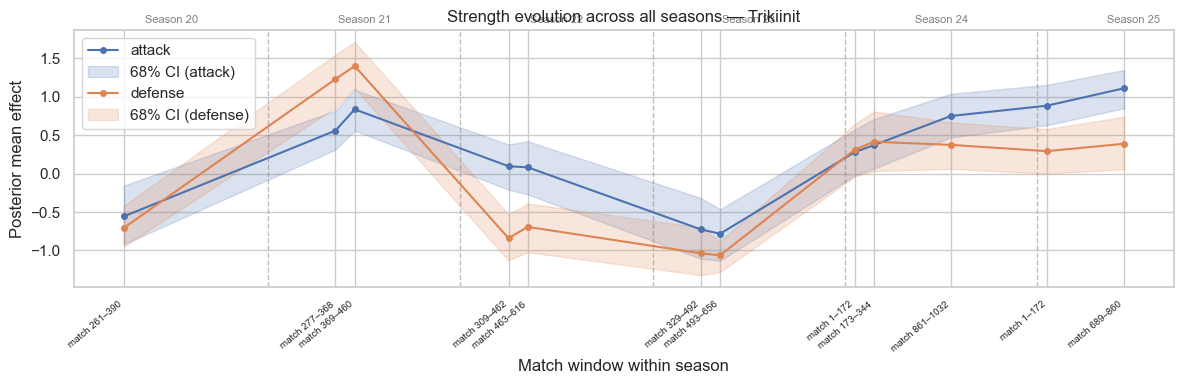

In [7]:
# Plot the full evolution — within-season windows and across-season continuity.
# Season boundaries are marked with dashed lines.
plot_all_seasons_evolution(joint_result, "Trikiinit")


In [ ]:
matches[(matches["season"]==25) & ((matches["home_team"]=="Trikiinit") | (matches["away_team"]=="Trikiinit"))]

In [ ]:
matches.head(50)